<a href="https://colab.research.google.com/github/Hend-Cheikhrouhou/Machine_Learning/blob/main/Pr%C3%A9traitement_(preprocessing)_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](attachment:image.png)

# Prétraitement (preprocessing)

Il s'agit toujours du même projet de Credit Scoring; de prédiction d'attribution de Crédits Habitat à une clientèle d'une Banque.

On va avancer dans le data science/machine learning pipeline. On va effectuer le prétraitement avec ses différentes étapes précisées dans le cours (Chapitre3ML)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import model_selection


In [ ]:

df1 = pd.read_csv("Partie1DatasetTP2.csv")
df1


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df2 = pd.read_csv("Partie2DatasetTP2.csv")
df2

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


## Avant de commencer le preprocessing

Il est préférable de copier les datasets d'origine car cette étape va effectuer des transformations sur les datasets d'origine


In [ ]:
train_original = df1.copy()
test_original = df2.copy()


# 2-Integration

In [ ]:
# On va fusionner les 2 datasets
df = pd.concat([df1,df2])
df.info()
df

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 366
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 107.3+ KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
363,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
364,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
365,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


# 1- Nettoyage (Cleaning)

## 1.1Valeurs manquantes  

In [ ]:
df1.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
df1.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
#On peut ajouter les pourcentages
total = df1.isnull().sum().sort_values(ascending=False)
percent = (df1.isnull().sum()/df1.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
Credit_History,50,0.081433
Self_Employed,32,0.052117
LoanAmount,22,0.035831
Dependents,15,0.024430
Loan_Amount_Term,14,0.022801
Gender,13,0.021173
Married,3,0.004886
Loan_ID,0,0.000000
Education,0,0.000000
ApplicantIncome,0,0.000000


###  Remplissage des vides pour Variables catégorielles

In [ ]:
print(df1.describe(include='object'))
# permet de savoir les var categ les plus fréquentes (rappel de tp2)

         Loan_ID Gender Married Dependents Education Self_Employed  \
count        614    601     611        599       614           582   
unique       614      2       2          4         2             2   
top     LP001002   Male     Yes          0  Graduate            No   
freq           1    489     398        345       480           500   

       Property_Area Loan_Status  
count            614         614  
unique             3           2  
top        Semiurban           Y  
freq             233         422  


In [ ]:
df1["Loan_Status"] = df1["Loan_Status"].replace(np.nan,"Y") #on a choisi de remplacer les valeurs non définies par yes
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


###  Remplissage des vides pour Variables numériques

In [ ]:
df1["LoanAmount"] = df1["LoanAmount"].replace(np.nan,df1['LoanAmount'].median())
df1


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:

df1["Gender"].fillna(df1["Gender"].mode()[0],inplace=True)

# ou
#df1["Gender"].fillna('Male',inplace=True)

In [ ]:
df1.isna().sum()   #on peut utiliser isnull

Loan_ID               0
Gender                0
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
df1["Married"].fillna(df1["Married"].mode()[0],inplace=True)


In [ ]:
df1["Dependents"].fillna(df1["Dependents"].mode()[0],inplace=True)

In [ ]:
df1["Self_Employed"].fillna(df1["Self_Employed"].mode()[0],inplace=True)

In [ ]:
df1["Loan_Amount_Term"] = df1["Loan_Amount_Term"].replace(np.nan,df1['Loan_Amount_Term'].median())
df1


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df1["Credit_History"].fillna(df1["Credit_History"].mode()[0],inplace=True)

In [ ]:
df1.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## A retenir

### Activité1
Refaire le même travail pour le reste des variables


## 1.2 Valeurs dupliquées

In [ ]:
df1.duplicated().any() #on vérifie s'il y a des duplications

False

In [ ]:
#Exemple explicatif
dfexemple = pd.DataFrame({

    'brand': ['Yum Yum', 'Yum Yum', 'Indomie', 'Indomie', 'Indomie'],

    'style': ['cup', 'cup', 'cup', 'pack', 'pack'],

    'rating': [4, 4, 3.5, 15, 5]

})

dfexemple.duplicated().any() # on va vérifier s'il y a des duplications
dfexemple

,brand,style,rating
0,Yum Yum,cup,4.0
1,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [ ]:
dfexemple.drop_duplicates()

,brand,style,rating
0,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [ ]:
df.drop_duplicates(keep=False, inplace=True)# keep = false on va supprimer tous les duplicates on ne va pas garder first ou last
#inplace= True ou Flase pour retourner une copie ou non
df.duplicated().any()

False

# 3-Transformation

## 3.1 Codage : Binarisation

In [ ]:
df1["Loan_Status"]= df1["Loan_Status"].replace("Y",1)
df1["Loan_Status"]= df1["Loan_Status"].replace("N",0)

df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [ ]:
df1["Married"]= df1["Married"].replace("Yes",1)
df1["Married"]= df1["Married"].replace("No",0)

df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,1,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,1,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,1,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [ ]:
df1["Education"]= df1["Education"].replace("Graduate",1)
df1["Education"]= df1["Education"].replace("Not Graduate",0)

df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0,0,1,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,1,1,1,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,1,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,1,3+,1,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,1,1,1,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,1,2,1,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [ ]:
df1["Self_Employed"]= df1["Self_Employed"].replace("Yes",1)
df1["Self_Employed"]= df1["Self_Employed"].replace("No",0)

df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,1,0,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,1,3+,1,0,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,1,1,1,0,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,1,2,1,0,7583,0.0,187.0,360.0,1.0,Urban,1


### Activité2
Faire de même pour les autres variables

## 3.2 Codage: Normalisation
Normalisation + Standardisation: Il s'agit d'une mise à l'échelle

In [ ]:
cols_to_normalize = ['LoanAmount','ApplicantIncome']
df1[cols_to_normalize] = df1[cols_to_normalize].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0,0,1,0,0.070489,0.0,0.172214,360.0,1.0,Urban,1
1,LP001003,Male,1,1,1,0,0.054830,1508.0,0.172214,360.0,1.0,Rural,0
2,LP001005,Male,1,0,1,1,0.035250,0.0,0.082489,360.0,1.0,Urban,1
3,LP001006,Male,1,0,0,0,0.030093,2358.0,0.160637,360.0,1.0,Urban,1
4,LP001008,Male,0,0,1,0,0.072356,0.0,0.191027,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,1,0,0.034014,0.0,0.089725,360.0,1.0,Rural,1
610,LP002979,Male,1,3+,1,0,0.048930,0.0,0.044863,180.0,1.0,Rural,1
611,LP002983,Male,1,1,1,0,0.097984,240.0,0.353111,360.0,1.0,Urban,1
612,LP002984,Male,1,2,1,0,0.091936,0.0,0.257598,360.0,1.0,Urban,1


### Activité3

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cols_to_normalize = ['LoanAmount', 'ApplicantIncome']
scaler = MinMaxScaler()

df1[cols_to_normalize] = scaler.fit_transform(df1[cols_to_normalize])


## 3.2 Codage: Standardisation

C:\Users\PC\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


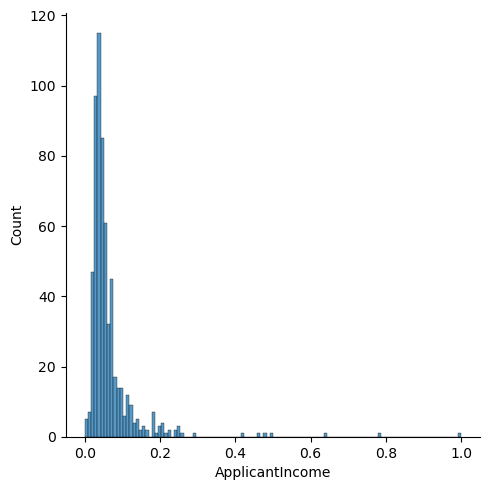

In [ ]:
import seaborn as sns

# Utilisation de displot à la place de distplot
sns.displot(df1["ApplicantIncome"]);

In [ ]:
from sklearn.preprocessing import StandardScaler

# Sélection de la colonne 'ApplicantIncome' et conversion en tableau NumPy
column_to_scale = df1['ApplicantIncome'].values[:, np.newaxis]

# Utilisation du StandardScaler pour normaliser la colonne
df1_scaled = StandardScaler().fit_transform(column_to_scale)


C:\Users\PC\AppData\Local\Temp\ipykernel_5596\2692967615.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df)


<Axes: ylabel='Density'>

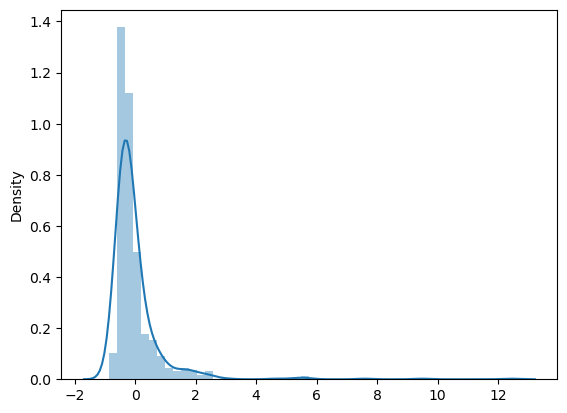

In [ ]:
data_df = pd.DataFrame(df1_scaled)
sns.distplot(data_df)

In [ ]:
# Sélection de la colonne 'ApplicantIncome' et conversion en tableau NumPy
column_to_scale = df1['CoapplicantIncome'].values[:, np.newaxis]

# Utilisation du StandardScaler pour normaliser la colonne
df1_scaled = StandardScaler().fit_transform(column_to_scale)


C:\Users\PC\AppData\Local\Temp\ipykernel_5596\2692967615.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df)


<Axes: ylabel='Density'>

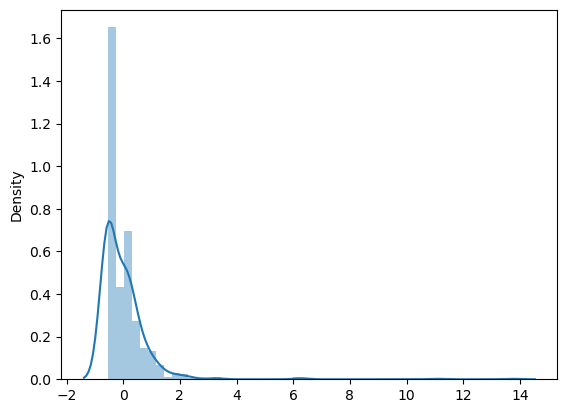

In [ ]:
data_df = pd.DataFrame(df1_scaled)
sns.distplot(data_df)

In [ ]:
# Sélection de la colonne 'ApplicantIncome' et conversion en tableau NumPy
column_to_scale = df1['LoanAmount'].values[:, np.newaxis]

# Utilisation du StandardScaler pour normaliser la colonne
df1_scaled = StandardScaler().fit_transform(column_to_scale)


C:\Users\PC\AppData\Local\Temp\ipykernel_5596\2692967615.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df)


<Axes: ylabel='Density'>

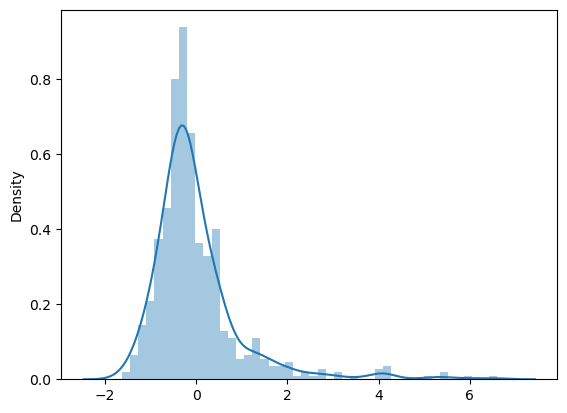

In [ ]:
data_df = pd.DataFrame(df1_scaled)
sns.distplot(data_df)

In [ ]:
# Sélection de la colonne 'ApplicantIncome' et conversion en tableau NumPy
column_to_scale = df1['Loan_Amount_Term'].values[:, np.newaxis]

# Utilisation du StandardScaler pour normaliser la colonne
df1_scaled = StandardScaler().fit_transform(column_to_scale)


C:\Users\PC\AppData\Local\Temp\ipykernel_5596\2692967615.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df)


<Axes: ylabel='Density'>

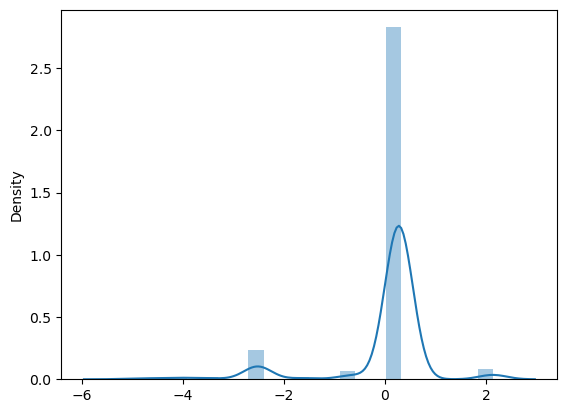

In [ ]:
data_df = pd.DataFrame(df1_scaled)
sns.distplot(data_df)

### Activité 4
Faire de même pour toute variable non centrée et réduite


##  3.3 Codage: Transformation d'attribut structuré

In [ ]:
#Variable dummy ou muette
dfdummy=pd.get_dummies(df1.Property_Area)
dfdummy

,Rural,Semiurban,Urban
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
609,True,False,False
610,True,False,False
611,False,False,True
612,False,False,True


In [ ]:
#On va coller les nouvelles variable catégorilles (dfdummy) dans la dataset df
Nouveaudf= pd.concat([df1,dfdummy], axis='columns')
Nouveaudf
#On va supprimer la colonne relative à la variable catégorielle du dataset vu qu'elle a été remplacée par les nouvelles
#colonnes
df1= Nouveaudf.drop(['Property_Area'], axis='columns')
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Rural,Semiurban,Urban
0,LP001002,Male,0,0,1,0,0.070489,0.0,0.172214,360.0,1.0,1,False,False,True
1,LP001003,Male,1,1,1,0,0.054830,1508.0,0.172214,360.0,1.0,0,True,False,False
2,LP001005,Male,1,0,1,1,0.035250,0.0,0.082489,360.0,1.0,1,False,False,True
3,LP001006,Male,1,0,0,0,0.030093,2358.0,0.160637,360.0,1.0,1,False,False,True
4,LP001008,Male,0,0,1,0,0.072356,0.0,0.191027,360.0,1.0,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,1,0,0.034014,0.0,0.089725,360.0,1.0,1,True,False,False
610,LP002979,Male,1,3+,1,0,0.048930,0.0,0.044863,180.0,1.0,1,True,False,False
611,LP002983,Male,1,1,1,0,0.097984,240.0,0.353111,360.0,1.0,1,False,False,True
612,LP002984,Male,1,2,1,0,0.091936,0.0,0.257598,360.0,1.0,1,False,False,True


In [ ]:
#Variable dummy ou muette
dfdummy=pd.get_dummies(df1.Gender)
dfdummy
#On va coller les nouvelles variable catégorilles (dfdummy) dans la dataset df
Nouveaudf= pd.concat([df1,dfdummy], axis='columns')
Nouveaudf
#On va supprimer la colonne relative à la variable catégorielle du dataset vu qu'elle a été remplacée par les nouvelles
#colonnes
df1= Nouveaudf.drop(['Gender'], axis='columns')
df1

,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Rural,Semiurban,Urban,Sum_Income,Female,Male
0,0,0,1,0,0.172214,360.0,1.0,1,False,False,True,0.070489,False,True
1,1,1,1,0,0.172214,360.0,1.0,0,True,False,False,1508.054830,False,True
2,1,0,1,1,0.082489,360.0,1.0,1,False,False,True,0.035250,False,True
3,1,0,0,0,0.160637,360.0,1.0,1,False,False,True,2358.030093,False,True
4,0,0,1,0,0.191027,360.0,1.0,1,False,False,True,0.072356,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,0.089725,360.0,1.0,1,True,False,False,0.034014,True,False
610,1,3+,1,0,0.044863,180.0,1.0,1,True,False,False,0.048930,False,True
611,1,1,1,0,0.353111,360.0,1.0,1,False,False,True,240.097984,False,True
612,1,2,1,0,0.257598,360.0,1.0,1,False,False,True,0.091936,False,True


### Activité 5
Faire de même pour les autres variables structurées si c'est nécessaire

## 3.4 Codage: Discrétisation

# 4-Réduction des données

## 4.1 Réduction de dimensions

In [ ]:
df1

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Rural,Semiurban,Urban
0,LP001002,Male,0,0,1,0,0.070489,0.0,0.172214,360.0,1.0,1,False,False,True
1,LP001003,Male,1,1,1,0,0.054830,1508.0,0.172214,360.0,1.0,0,True,False,False
2,LP001005,Male,1,0,1,1,0.035250,0.0,0.082489,360.0,1.0,1,False,False,True
3,LP001006,Male,1,0,0,0,0.030093,2358.0,0.160637,360.0,1.0,1,False,False,True
4,LP001008,Male,0,0,1,0,0.072356,0.0,0.191027,360.0,1.0,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,0,1,0,0.034014,0.0,0.089725,360.0,1.0,1,True,False,False
610,LP002979,Male,1,3+,1,0,0.048930,0.0,0.044863,180.0,1.0,1,True,False,False
611,LP002983,Male,1,1,1,0,0.097984,240.0,0.353111,360.0,1.0,1,False,False,True
612,LP002984,Male,1,2,1,0,0.091936,0.0,0.257598,360.0,1.0,1,False,False,True


In [ ]:
#On va enlever Loan_Id vu que ce n'est pas un attribut important
df1.drop("Loan_ID",axis=1,inplace=True)

In [ ]:
df1.shape

(614, 14)

In [ ]:
df1

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Rural,Semiurban,Urban
0,Male,0,0,1,0,0.070489,0.0,0.172214,360.0,1.0,1,False,False,True
1,Male,1,1,1,0,0.054830,1508.0,0.172214,360.0,1.0,0,True,False,False
2,Male,1,0,1,1,0.035250,0.0,0.082489,360.0,1.0,1,False,False,True
3,Male,1,0,0,0,0.030093,2358.0,0.160637,360.0,1.0,1,False,False,True
4,Male,0,0,1,0,0.072356,0.0,0.191027,360.0,1.0,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,0,0,1,0,0.034014,0.0,0.089725,360.0,1.0,1,True,False,False
610,Male,1,3+,1,0,0.048930,0.0,0.044863,180.0,1.0,1,True,False,False
611,Male,1,1,1,0,0.097984,240.0,0.353111,360.0,1.0,1,False,False,True
612,Male,1,2,1,0,0.091936,0.0,0.257598,360.0,1.0,1,False,False,True


### Activité6

In [ ]:
df1['Sum_Income']=df1['ApplicantIncome']+df1['CoapplicantIncome']
df1.drop(['ApplicantIncome', 'CoapplicantIncome'],axis =1, inplace=True)


In [ ]:
df1

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Rural,Semiurban,Urban,Sum_Income
0,Male,0,0,1,0,0.172214,360.0,1.0,1,False,False,True,0.070489
1,Male,1,1,1,0,0.172214,360.0,1.0,0,True,False,False,1508.054830
2,Male,1,0,1,1,0.082489,360.0,1.0,1,False,False,True,0.035250
3,Male,1,0,0,0,0.160637,360.0,1.0,1,False,False,True,2358.030093
4,Male,0,0,1,0,0.191027,360.0,1.0,1,False,False,True,0.072356
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,0,0,1,0,0.089725,360.0,1.0,1,True,False,False,0.034014
610,Male,1,3+,1,0,0.044863,180.0,1.0,1,True,False,False,0.048930
611,Male,1,1,1,0,0.353111,360.0,1.0,1,False,False,True,240.097984
612,Male,1,2,1,0,0.257598,360.0,1.0,1,False,False,True,0.091936


## 4.2 Réduction de numérosité: échantillonage

In [ ]:
#Supposons qu'on veut travailler sur X égal à la varible LoanAmount
X = df1[['LoanAmount']]
Y= df1[['Loan_Status']]
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X,Y, test_size=0.2)
print (X_train.shape)
print (X_test.shape)
print(Y_train)
print (Y_test)

(491, 1)
(123, 1)
     Loan_Status
104            1
613            0
410            0
326            1
185            1
..           ...
501            1
86             1
375            1
330            1
122            1

[491 rows x 1 columns]
     Loan_Status
418            1
23             0
277            1
372            1
90             1
..           ...
192            0
570            1
562            1
261            1
564            0

[123 rows x 1 columns]


### Activité 7
On veut que la taille de l'ensemble d'apprentissage soit 70% de la taille du dataset

In [ ]:
#Supposons qu'on veut travailler sur X égal à la varible LoanAmount
X = df1[['LoanAmount']]
Y= df1[['Loan_Status']]
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X,Y, test_size=0.3)
print (X_train.shape)
print (X_test.shape)
print(Y_train)
print (Y_test)

(429, 1)
(185, 1)
     Loan_Status
342            1
161            0
242            1
83             0
437            1
..           ...
237            1
80             1
258            0
404            0
222            1

[429 rows x 1 columns]
     Loan_Status
141            1
267            1
205            1
203            1
132            1
..           ...
363            1
562            1
512            1
218            0
152            0

[185 rows x 1 columns]


## Remarques importantes